<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [2]:
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [3]:
# Load the Stack Overflow survey data
file_name = "survey_data.csv"
df = pd.read_csv(file_name)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10052\3648536680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_count.values, y=industry_count.index, palette="viridis")


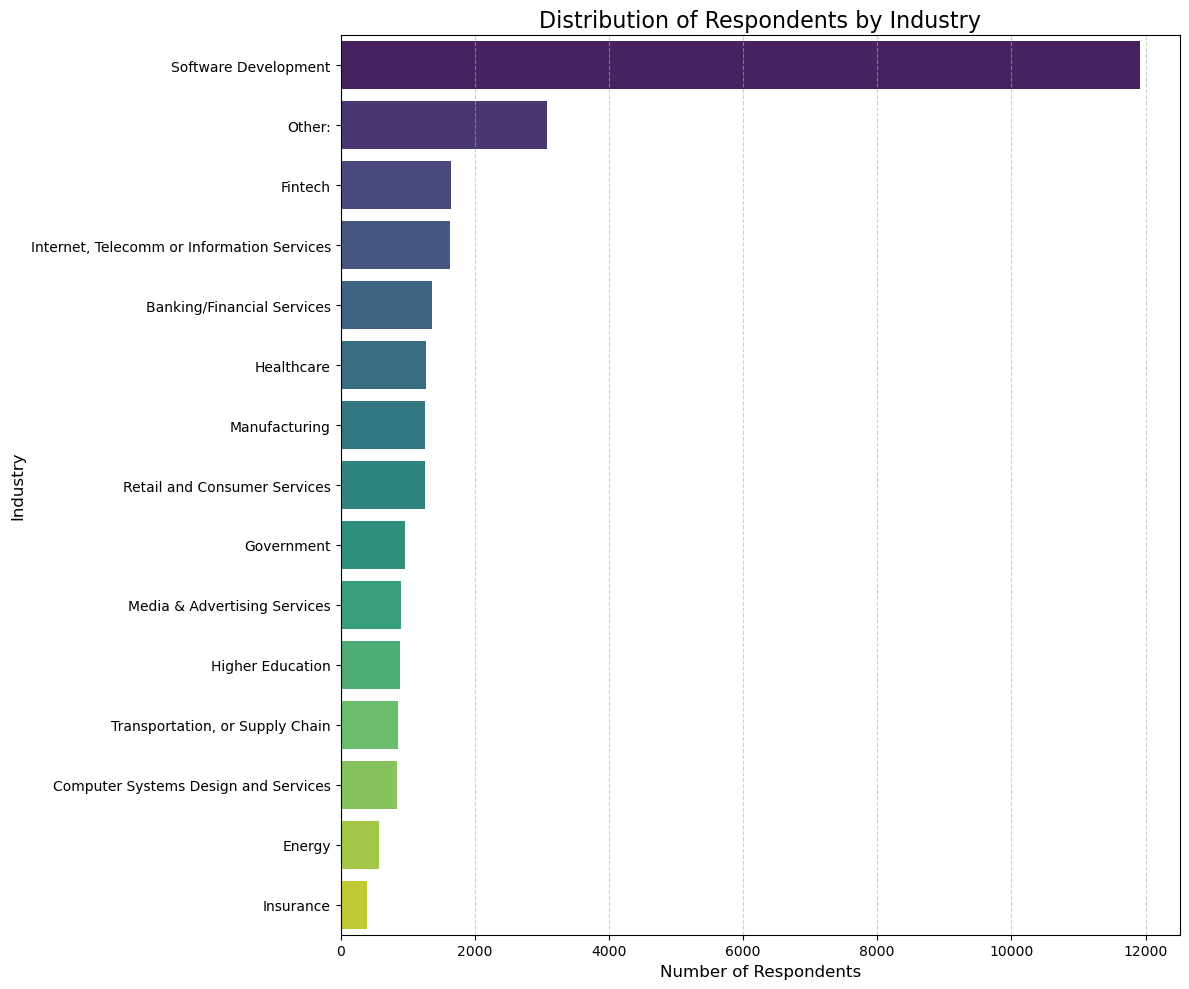

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. حساب تكرار كل صناعة وترتيبها تصاعدياً (كما في كودك)
industry_count = df["Industry"].value_counts().sort_values(ascending=False)

# 2. إعداد حجم الرسم
plt.figure(figsize=(12, 10))

# 3. رسم المخطط الشريطي الأفقي باستخدام Seaborn
sns.barplot(x=industry_count.values, y=industry_count.index, palette="viridis")

# 4. إضافة العناوين والملصقات بالإنجليزية
plt.title("Distribution of Respondents by Industry", fontsize=16)
plt.xlabel("Number of Respondents", fontsize=12)
plt.ylabel("Industry", fontsize=12)

# 5. إضافة شبكة خلفية لتسهيل قراءة الأرقام
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
import pandas as pd

# 1. حساب الإحصائيات الأساسية لعمود الرواتب
# نتأكد أولاً من حذف القيم المفقودة للحصول على حسابات دقيقة
comp_data = df['ConvertedCompYearly'].dropna()

mean_val = comp_data.mean()
median_val = comp_data.median()
std_val = comp_data.std()

print(f"--- Basic Statistics ---")
print(f"Mean (المتوسط): ${mean_val:,.2f}")
print(f"Median (الوسيط): ${median_val:,.2f}")
print(f"Standard Deviation (الانحراف المعياري): ${std_val:,.2f}")

# 2. تحديد حد القيم الشاذة (3 انحرافات معيارية فوق المتوسط)
threshold = mean_val + (3 * std_val)
print(f"\nOutlier Threshold (حد القيم الشاذة): ${threshold:,.2f}")

# 3. تحديد المشاركين الذين يتجاوزون هذا الحد
outliers = df[df['ConvertedCompYearly'] > threshold]

print(f"\nNumber of high compensation outliers: {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers) / len(df)) * 100:.2f}%")

# عرض أعلى 5 رواتب تم تحديدها كقيم شاذة
print("\n--- Top 5 Outliers ---")
print(outliers[['ResponseId', 'Country', 'ConvertedCompYearly']].sort_values(by='ConvertedCompYearly', ascending=False).head())

--- Basic Statistics ---
Mean (المتوسط): $86,155.29
Median (الوسيط): $65,000.00
Standard Deviation (الانحراف المعياري): $186,756.97

Outlier Threshold (حد القيم الشاذة): $646,426.21

Number of high compensation outliers: 89
Percentage of outliers: 0.14%

--- Top 5 Outliers ---
       ResponseId       Country  ConvertedCompYearly
15837       15838      Ethiopia           16256603.0
12723       12724  South Africa           13818022.0
28379       28380        Taiwan            9000000.0
17593       17594        Brazil            6340564.0
17672       17673       Ukraine            4936778.0


In [6]:
# إنشاء نسخة نظيفة من البيانات بدون القيم الشاذة
# سنبقي فقط الرواتب التي تقع تحت حد الـ 646,426 دولار
df_final = df[df['ConvertedCompYearly'] <= 646426]

print(f"المتوسط الجديد بعد التنظيف: ${df_final['ConvertedCompYearly'].mean():,.2f}")
print(f"الانحراف المعياري الجديد: ${df_final['ConvertedCompYearly'].std():,.2f}")

المتوسط الجديد بعد التنظيف: $80,293.09
الانحراف المعياري الجديد: $69,642.78


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR: $75,259.50
Lower Bound: $-80,177.25
Upper Bound: $220,860.75

Number of Outliers (IQR Method): 978


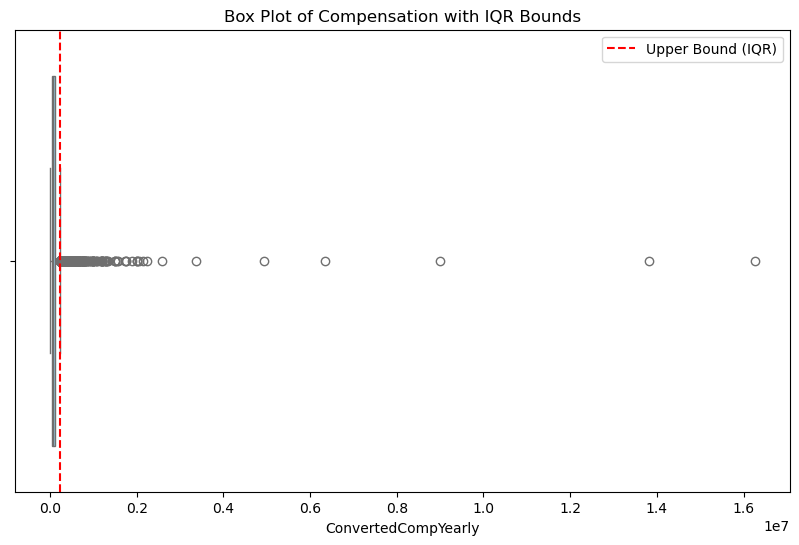

In [7]:
# 1. حساب الربيعيات (Quartiles)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# 2. حساب المدى الربيعي (IQR)
IQR = Q3 - Q1

# 3. تحديد الحدود (Lower & Upper Bounds)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f}")
print(f"Upper Bound: ${upper_bound:,.2f}")

# 4. تحديد وحساب القيم الشاذة
iqr_outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(f"\nNumber of Outliers (IQR Method): {len(iqr_outliers)}")

# 5. التمثيل البصري باستخدام Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['ConvertedCompYearly'], color='skyblue')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound (IQR)')
plt.title('Box Plot of Compensation with IQR Bounds')
plt.legend()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [8]:
# 1. حساب القيم الضرورية للـ IQR (تأكيد الحسابات)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# 2. تحديد الحدود
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. إنشاء DataFrame جديد باستبعاد القيم الشاذة
# نختار فقط الصفوف التي تقع داخل الحدود (أكبر من الحد الأدنى وأصغر من الحد الأقصى)
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                    (df['ConvertedCompYearly'] <= upper_bound)]

# 4. التحقق من حجم البيانات الجديد (Validation)
original_size = len(df)
new_size = len(df_no_outliers)
outliers_removed = original_size - new_size

print(f"--- Validation Summary ---")
print(f"Original DataFrame size: {original_size} rows")
print(f"New DataFrame size: {new_size} rows")
print(f"Total outliers removed: {outliers_removed} rows")
print(f"Percentage of data retained: {(new_size/original_size)*100:.2f}%")

--- Validation Summary ---
Original DataFrame size: 65437 rows
New DataFrame size: 22457 rows
Total outliers removed: 42980 rows
Percentage of data retained: 34.32%


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [9]:
# تعريف القاموس للتحويل (بناءً على فئات Stack Overflow الشائعة)
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 68,
    'Prefer not to say': np.nan
}

# تطبيق التحويل على الـ DataFrame النظيف (df_no_outliers)
df_no_outliers['Age_Numeric'] = df_no_outliers['Age'].map(age_mapping)

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10052\428098205.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['Age_Numeric'] = df_no_outliers['Age'].map(age_mapping)


In [10]:

# 2. التأكد من تحويل الرضا الوظيفي (JobSat) إلى أرقام في النسخة الجديدة
# سنستخدم .copy() لتجنب تحذيرات SettingWithCopyWarning
sat_mapping = {
    'Very satisfied': 5, 'Satisfied': 4, 'Neither satisfied nor dissatisfied': 3,
    'Dissatisfied': 2, 'Very dissatisfied': 1
}
df_no_outliers['JobSat_Num'] = df_no_outliers['JobSat'].map(sat_mapping)

# 3. التأكد من أن YearsCodePro رقمي (معالجة النصوص مثل 'Less than 1 year')
df_no_outliers['YearsCodePro'] = pd.to_numeric(
    df_no_outliers['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51}), 
    errors='coerce'
)

# 4. الآن نختار الأعمدة الموجودة فعلياً
numerical_cols = ['Age_Numeric', 'YearsCodePro', 'ConvertedCompYearly', 'WorkExp', 'JobSat_Num']

# حساب المصفوفة (مع حذف القيم المفقودة أثناء الحساب)
corr_matrix = df_no_outliers[numerical_cols].corr()

print("Correlation Matrix for Age_Numeric:")
print(corr_matrix['Age_Numeric'].sort_values(ascending=False))

Correlation Matrix for Age_Numeric:
Age_Numeric            1.000000
WorkExp                0.846405
YearsCodePro           0.823297
ConvertedCompYearly    0.368800
JobSat_Num                  NaN
Name: Age_Numeric, dtype: float64


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10052\2496107176.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['JobSat_Num'] = df_no_outliers['JobSat'].map(sat_mapping)
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10052\2496107176.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['YearsCodePro'] = pd.to_numeric(


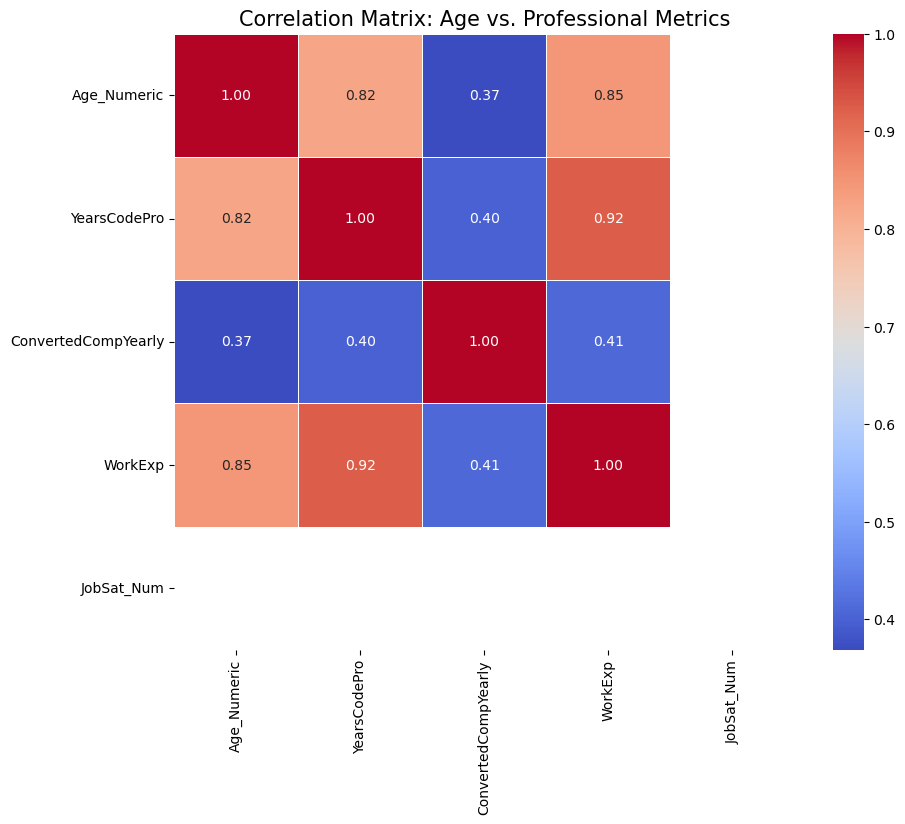

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix: Age vs. Professional Metrics', fontsize=15)
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
